Problem kya hota hai?

Socho tum Linear Regression use kar rahe ho (line fit karna data pe).

Kab problem aati hai?

👉 Jab:

features bahut zyada ho (too many columns)
ya features ek dusre se similar ho (multicollinearity)

Result:
❌ model overfit karta hai

❌ coefficients (weights) bahut bade ho jaate hain

❌ prediction unstable ho jaata hai

# Define

"Ye model ko control me rakhta hai by punishing big weights"

Means:

agar koi coefficient (weight) bahut bada ho raha hai
➡️ Ridge usko chota kar deta h

# Formula

Loss function:

Error + λ * (sum of squares of weights)

Lambda (λ) ka role

👉 Ye sabse important concept hai

λ = 0 → normal linear regression

λ ↑ → penalty ↑ → weights chhote

# Kab use karte hain?

features zyada ho

multicollinearity ho (features similar ho)

overfitting ho raha ho

# coefficients zero nahi hote, bas chhote hote hain

# Ridge Regression = Linear Regression + L2 penalty (weights ko chhota karna)

# Core idea

👉 Model ko overfit hone se bachata hai

👉 Bade coefficients ko shrink karta hai (but zero nahi karta)

# CODE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [ ]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
X=data.data
y=data.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [ ]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [ ]:
L.fit(X_train,y_train)

LinearRegression()

In [ ]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [ ]:
y_pred=L.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539249
RMSE 48.72713760953253


In [ ]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=100000)

In [ ]:
R.fit(X_train,y_train)

Ridge(alpha=100000)

In [ ]:
print(R.coef_)
print(R.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [ ]:
y_pred1=R.predict(X_test)

In [ ]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00042490200441935855
RMSE 70.25956272917782


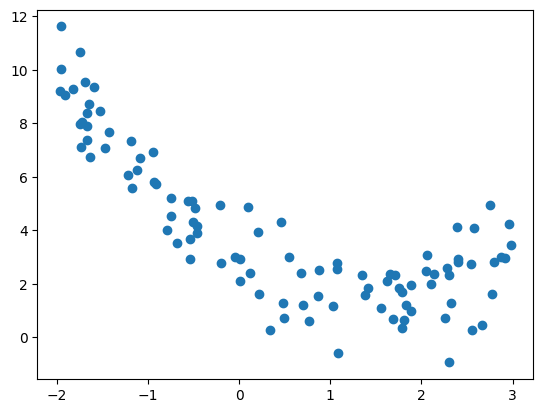

In [ ]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()


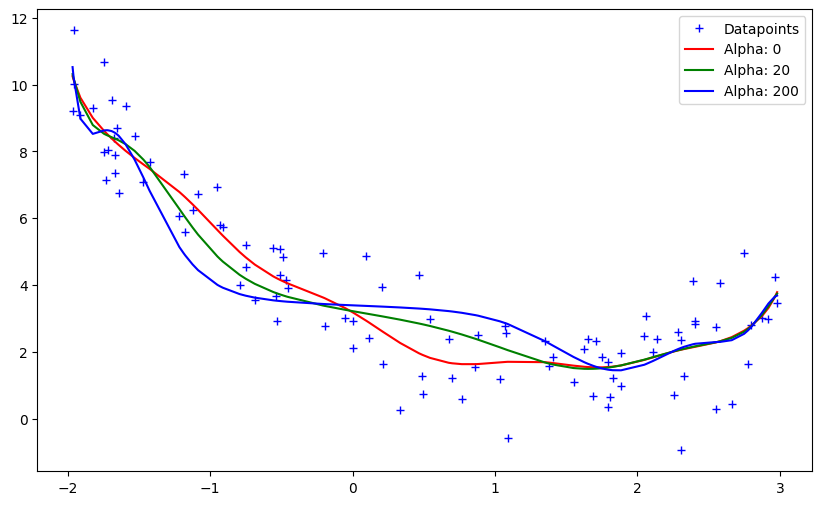

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

# From Scratch code

In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


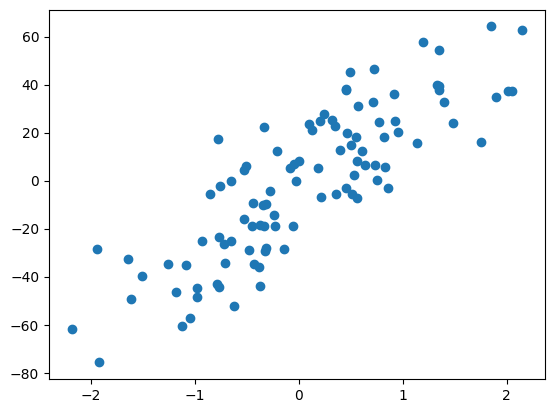

In [ ]:
plt.scatter(X,y)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:

lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [ ]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


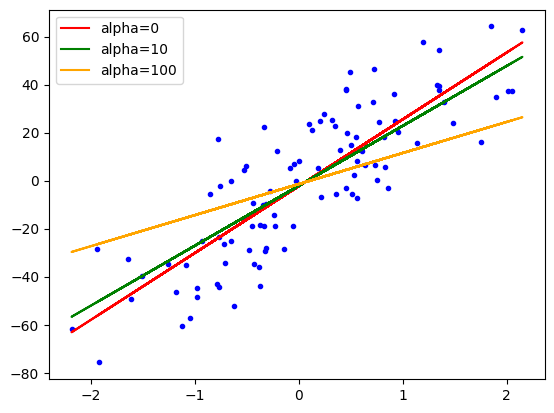

In [ ]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [ ]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()

    num = 0
    den = 0

    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)

    m = num/(den + alpha)
    b = y_mean - m*x_mean

    return m,b

In [ ]:
class MeraRidge:

    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)

    def predict(X_test):
        pass

In [ ]:
reg = MeraRidge(alpha=100)


In [ ]:
reg.fit(X,y)

[12.93442104] [-1.42484415]


#  Ridge Regression for N-Dimensional Data


# Step 1: Sabse pehle Regression kya hai?



In [ ]:
Maan lo tum ghar ki price predict karna chahte ho.

Features hain:

Size
Bedrooms
Location Score

Linear Regression bolta hai:

"Main in sab features ko weight (importance) dunga."

Price = w1(Size)+w2(Bedrooms)+w3(Location)+b

 = weights
b = bias

# Step 2: Problem kab aati hai?

In [ ]:
Kabhi kabhi model aise weights bana deta hai

w1 = 985423

w2 = -754221

w3 = 543212

Ye bahut bade numbers hain.

Isse problem hoti hai.

Ye problem kya hai?

Model training data ko rat leta hai.

Jaise student.

Student A

Concept samjha

Exam me bhi achha.

Student B

Sirf answers rat liye.

Exam badla

Fail.

Isi ko ML me bolte hain

Overfitting

# Step 3: Overfitting ko kaise rokna?

In [ ]:
Teacher bolta hai

"Itne bade weights mat banao."

ML me bhi wahi karte hain.

Aur isi idea ka naam hai

Ridge Regression

# Step 4: Ridge kya karta hai?

In [ ]:
Ye model se bolta hai

"Prediction bhi sahi honi chahiye,
lekin weights bhi chhote hone chahiye."

Matlab

Ye

w1 = 800000

ko pasand nahi karega.

Ye chahega

w1 = 30

w2 = 5

w3 = 10

# Step 5: Iske liye extra punishment lagti hai

In [ ]:
Normal Linear Regression sirf error dekhta hai.

Error = Actual - Prediction

Ridge bolta hai

Total Loss

=

Prediction Error

+

Penalty

Penalty kis baat ki?

Bade weights ki.

# Step 6: Penalty ka formula

In [ ]:
Loss=Error+λ(w1^2+w2^2+w3^2+___+wn^2)

Darne ki zarurat nahi.

Isko tukdo me samjho.

Error

Prediction kitni galat hai.

Lambda

Kitni punishment deni hai.

Weights²

Jitna bada weight

utni badi punishment

# Step 7: Weight square kyu?

In [ ]:
Suppose

weight = 2

2² = 4

Aur

weight = 20

20² = 400

Dekho difference

2 → 4

20 → 400

Large weight ko bahut zyada punishment.

Isi liye square.

# Step 8: Lambda kya hai?

In [ ]:
Lambda ek control knob hai.

Lambda = 0
No punishment

Ye normal Linear Regression ban gaya.

Lambda = small
Thodi punishment

Weights thode kam honge.

Lambda = large
Bahut punishment

Weights bahut chhote ho jayenge.

# Step 9: N-Dimensional Data kya hota hai?

In [ ]:
Ye sabse easy hai.

Dimension matlab

Feature.

Example

Ek feature

Height

To

1-D

Do feature

Height

Weight

To

2-D

Teen feature

Height

Weight

Age

To

3-D

100 features

Income

Age

Experience

CGPA

Skills

Projects

...
100 total

Ye ho gaya

100-Dimensional Data

 # Step 10: Ridge for N-Dimensional Data

In [ ]:
Ab maan lo

Tumhare paas

500 features

To equation hogi
        y = w1x1+w2x2+w3x3+___+w500x500+b

aur ridge bolega

       Loss=Error+λ(w1^2+w2^2+w3^2+___+w500^2)
Matlab

Har feature ke weight ko check karega.

Jo bada hoga

Usko shrink karega.

#Step 11: Real Life Analogy

In [ ]:
Socho tum ek truck chala rahe ho.

Truck me 100 boxes hain.

Har box ka weight ek feature ka weight hai.

Agar kuch boxes bahut heavy hain

200 kg

300 kg

500 kg

Truck unstable ho jayega.

Ridge bolta hai

"Sab boxes ka weight thoda balance kar do."

Ab truck smoothly chalega.

Yahi Ridge karta hai.

# Code

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [2]:

X,y = load_diabetes(return_X_y=True)

In [3]:

from sklearn.model_selection import train_test_split

In [4]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [5]:
from sklearn.linear_model import Ridge

In [6]:
reg = Ridge(alpha=0.1,solver='cholesky')

In [7]:

reg.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [8]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [9]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [10]:
class MeraRidge:

    def __init__(self,alpha=0.1):

        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [15]:
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281


# Ridge Regression trained using Gradient Descent?

```

# Step 1: Normal Linear Regression

Suppose hamara model hai

y
^
	​

=w
1
	​

x
1
	​

+w
2
	​

x
2
	​

+⋯+w
n
	​

x
n
	​

+b

Goal:

Prediction ko actual value ke jitna close laana.

# Step 2: Loss Function

Linear Regression sirf prediction error minimize karta hai.

Loss=
m
1
	​

i=1
∑
m
	​

(y
i
	​

−
y
^
	​

i
	​

)
2

Yaha

m = number of samples
y = actual value
ŷ = predicted value

Gradient Descent isi loss ko minimize karta hai.

#Step 3: Ridge Regression me kya change hua?

Ridge bolta hai

"Prediction error bhi kam karo aur weights ko bhi chhota rakho."

Isliye ek extra penalty add hoti hai.

Loss function ban jata hai

J(w)=
m
1
	​

i=1
∑
m
	​

(y
i
	​

−
y
^
	​

i
	​

)
2
+λ
j=1
∑
n
	​

w
j
2
	​


Yaha

First part = Prediction Error
Second part = L2 Penalty
# Step 4: Gradient Descent ka kaam

Gradient Descent ka rule hamesha same hota hai

w=w−α
∂w
∂J
	​

	​


Jaha

α = Learning Rate
J = Loss Function

Ab hame sirf gradient nikalna hai.

# Step 5: Gradient of Ridge Loss

Loss ke do parts hain.

Part 1

Prediction Error

Iska derivative hota hai

−
m
2
	​

X
T
(y−
y
^
	​

)
Part 2

Penalty

λw
2

Derivative

2λw

Ye extra term sirf Ridge me add hoti hai.

# Step 6: Final Gradient

Gradient ban gaya

∂w
∂J
	​

=−
m
2
	​

X
T
(y−
y
^
	​

)+2λw
	​


Dhyan do.

Ye + 2λw hi Ridge ko special banata hai.

# Step 7: Weight Update

Gradient Descent update

w=w−α(−
m
2
	​

X
T
(y−
y
^
	​

)+2λw)

Yahi Ridge Regression ka Gradient Descent formula hai.

# Step 8: Ye extra term karta kya hai?

Suppose

Current weight = 20

λ = 0.5

2λw

= 2 × 0.5 × 20

=20

Update

w = 20 − α(gradient + 20)

Notice karo

Weight ko aur niche push kiya ja raha hai.

Agar

Weight = 2

Penalty

2 × 0.5 × 2

=2

Chhote weight ko kam punishment.

Agar

Weight = 100

Penalty

2 × 0.5 ×100

=100

Bahut zyada punishment.

Isi liye bade weights shrink hote hain.

# Step 9: Ek Iteration ka Dry Run

Suppose

Weight = 10

Learning Rate = 0.1

Prediction Gradient = 4

λ = 0.5

Penalty Gradient

2λw

=2×0.5×10

=10

Total Gradient

4 + 10

=14

Update

w = 10 − 0.1×14

=10−1.4

=8.6

Dekho

Old Weight =10

New Weight =8.6

Weight aur chhota ho gaya.

Isi ko Weight Shrinkage bolte hain.

# Step 10: Algorithm
Initialize weights randomly

Repeat until convergence:

1. Predict
      ŷ = Xw + b

2. Compute Loss
      Error + λΣw²

3. Compute Gradient
      Error Gradient + 2λw

4. Update Weights
      w = w − α × Gradient

Return final weights

```

# Ridge Regression me pehle hum prediction karte hain aur uska error calculate karte hain. Lekin Linear Regression se alag, Ridge ek extra penalty term (λw²) bhi loss function me add karta hai taaki model bahut bade weights na bana de. Jab Gradient Descent gradient calculate karta hai, to normal prediction error ke gradient ke saath 2λw bhi add ho jata hai. Phir weights ko update kiya jata hai using w = w − α(Gradient + 2λw), jahan α learning rate hoti hai. Har iteration me ye 2λw term bade weights ko dheere-dheere chhota (shrink) karti rehti hai, jiski wajah se model overfitting se bachta hai aur naye data par bhi achha perform karta hai. Bas yaad rakho: Linear Regression sirf error kam karta hai, jabki Ridge Regression error ke saath-saath bade weights ko bhi chhota karta hai.

# Code

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [17]:

X,y = load_diabetes(return_X_y=True)

In [18]:

from sklearn.model_selection import train_test_split

In [19]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [20]:
from sklearn.linear_model import SGDRegressor

In [21]:

reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [22]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.45274410089824835
[  50.55292656 -157.19345578  369.19415143  268.30722974   -5.4791015
  -58.55330618 -163.84230479  136.56673677  327.56116946  100.24248721]
[162.69283819]


In [23]:

from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [24]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.46250101619914563
[  34.52192544 -290.84084076  482.40181344  368.0678662  -852.44873179
  501.59160336  180.11115788  270.76333979  759.73534372   37.4913546 ]
151.10198517439466


In [25]:
class MeraRidgeGD:

    def __init__(self,epochs,learning_rate,alpha):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)

        X_train = np.insert(X_train,0,1,axis=1)

        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der

        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]

    def predict(self,X_test):

        return np.dot(X_test,self.coef_) + self.intercept_

In [26]:

reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [27]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4738018280260913
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472


#    5 Key Points - Ridge Regression

# How the coefficients get affected?

Coefficient (weight) Ridge Regression me directly affect hote hain kyunki Gradient Descent har iteration me unhe update karta hai. Jab loss function me L2 penalty (λw²) add hoti hai, to gradient me ek extra term 2λw aa jati hai. Agar kisi coefficient ki value bahut badi hai, to 2λw bhi badi hogi, isliye Gradient Descent us coefficient ko zyada amount se reduce karega. Agar coefficient pehle se hi chhota hai, to uski penalty bhi chhoti hogi aur usme kam change aayega. Is process ko coefficient shrinkage kehte hain. Isliye Ridge Regression me coefficients exactly zero nahi hote, balki dheere-dheere chhote hote jate hain, jisse model kisi ek feature par bahut zyada depend nahi karta aur overfitting kam ho jati hai.

# Important line

Because saare shrink karte hai 0 ki taraf but 0 nhi hote 0 ke close hote hai isliye .

# Example

Socho tum ek team bana rahe ho.

Tumhare paas 5 players hain.

Har player ko tum importance (coefficient) de rahe ho.

Player A = 100

Player B = 80

Player C = 5

Player D = 10

Player E = 2

Yaha coefficient ka matlab hai feature ki importance.

Ab maan lo Player A ko tumne 100 importance de di. Matlab model lagbhag sirf usi player par depend kar raha hai. Agar wo player ek din kharab khel gaya, to poori team haar sakti hai. Ye hi Machine Learning me overfitting hai.

Ab Ridge Regression aata hai aur bolta hai:

"Ek hi player ko itni importance mat do. Sabko thoda balanced importance do."

Isliye Ridge har training step (Gradient Descent) me bade coefficients ko thoda-thoda kam karta rehta hai.

Jaise:

100 → 90 → 82 → 75 → 68 → ...

Aur agar kisi player ki importance pehle se hi kam hai, jaise 5, to Ridge usko bahut kam reduce karega.

5 → 4.8 → 4.7 → 4.6

Notice karo:

Bada coefficient zyada kam hua.
Chhota coefficient bahut kam change hua.

Aisa isliye hota hai kyunki Gradient Descent me ek extra penalty (2λw) add hoti hai. Jitna bada coefficient (w) hoga, utni badi penalty lagegi, aur utna hi zyada wo reduce hoga.

# Code

In [28]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [29]:
data = load_diabetes()

In [30]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [32]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [34]:
df.shape

(442, 11)

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [36]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [37]:
coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

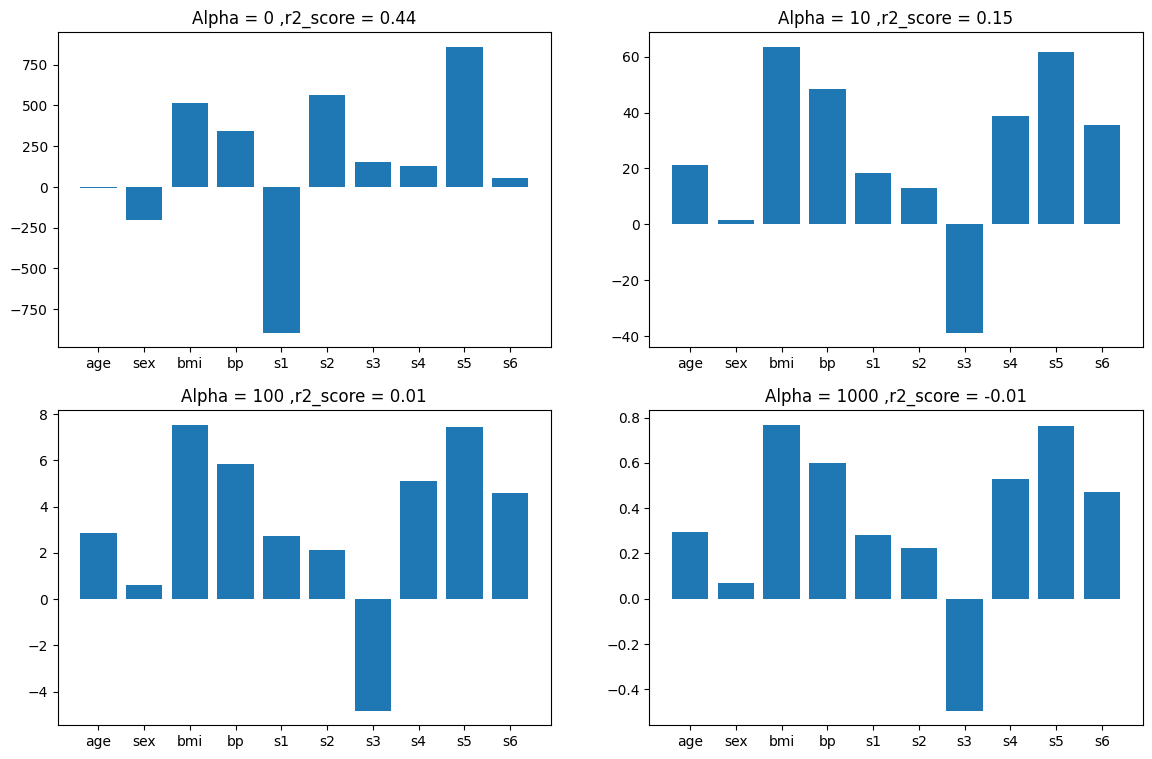

In [38]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

# Higher Values are impacted more

Ridge Regression me higher coefficient values zyada impact hoti hain kyunki penalty coefficient ki value ke proportional hoti hai. Gradient Descent ke time ek extra term 2λw add hoti hai. Yahan w coefficient ki value hai, isliye agar coefficient bada hoga (jaise 100), to 2λw bhi bada hoga aur us coefficient ko zyada reduce kiya jayega. Agar coefficient chhota hoga (jaise 5), to penalty bhi chhoti hogi aur usme kam change aayega. Simple reason ye hai ki Ridge ka goal bahut bade coefficients ko control karna hai, kyunki bade coefficients model ko kisi ek feature par bahut zyada dependent bana dete hain, jisse overfitting ho sakti hai. Isliye Ridge bade coefficients ko zyada shrink karta hai aur chhote coefficients ko kam affect karta hai.

Haan, higher coefficient values are impacted more. Isko ekdum easy way me samjho.

Suppose do coefficients hain:

Feature A coefficient = 100

Feature B coefficient = 5

Ridge Regression me penalty gradient hota hai:

2λw

Agar λ = 0.5 ho,

Feature A:

2 × 0.5 × 100 = 100

Feature B:

2 × 0.5 × 5 = 5

Dekho, Feature A ko 100 ki penalty mili, jabki Feature B ko sirf 5 ki penalty mili. Isliye Gradient Descent 100 wale coefficient ko zyada reduce karega aur 5 wale coefficient ko bahut kam reduce karega.

Easy Real-Life Analogy

Socho school me rule hai:

"Jis student ne zyada shor machaya, usko zyada punishment milegi."

Student A ne bahut shor machaya → Badi punishment
Student B ne thoda shor machaya → Chhoti punishment

Bilkul waise hi Ridge Regression me:

Bada coefficient → Badi penalty → Zyada shrink hoga
Chhota coefficient → Chhoti penalty → Thoda shrink hoga

# Code

In [39]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

In [40]:
input_array = np.array(coefs)

In [41]:
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [42]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

In [43]:
input_array = np.array(coefs).T

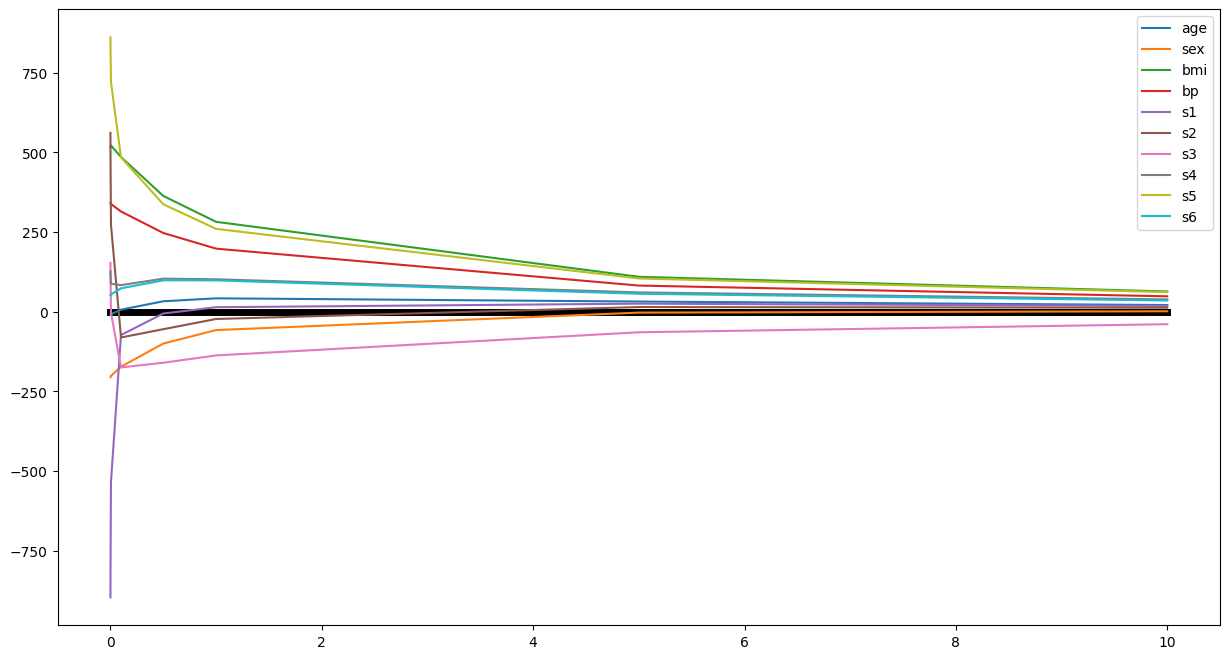

In [44]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

# Impact on Bias variance TradeOff

Ridge Regression coefficients ko shrink karta hai, jisse model simple ho jata hai. Simple model training data ko overfit nahi karta, isliye variance decrease hoti hai. Lekin simplicity ki wajah se training data par kuch error badh sakta hai, isliye bias thoda increase hota hai. Yehi Bias-Variance Tradeoff hai—Ridge thoda bias badhakar variance ko kaafi reduce karta hai, jisse overall generalization improve hoti hai.

# Exmaple

Socho ek student exam ki tayari kar raha hai.

Case 1: Sirf ratta maar liya (Overfitting)

Student ne har question yaad kar liya.

School exam me 100%
Naye questions aaye → Fail

Ye High Variance, Low Bias hai.

Model training data ko hi yaad kar leta hai.

Ridge kya karta hai?

Ridge bolta hai:

"Itna ratta mat maaro, concepts bhi samjho."

Isliye Ridge model ko simple banata hai.

Jab coefficients chhote ho jate hain, model training data ko ratta nahi marta.

Isse

✅ Variance kam ho jati hai.

Lekin ek problem

Kyuki model simple ho gaya, ho sakta hai training data par perfect prediction na kare.

Matlab thodi galti badh gayi.

Ye hota hai

✅ Bias thoda increase ho jata hai.

Final Effect

Bias ↑ (thoda badhta hai) because model ko simple banaya ja raha hai.

Variance ↓ (kam hoti hai) because model overfitting nahi karta.

Overall model better generalize karta hai, yani naye (unseen) data par achha perform karta hai.

# Code

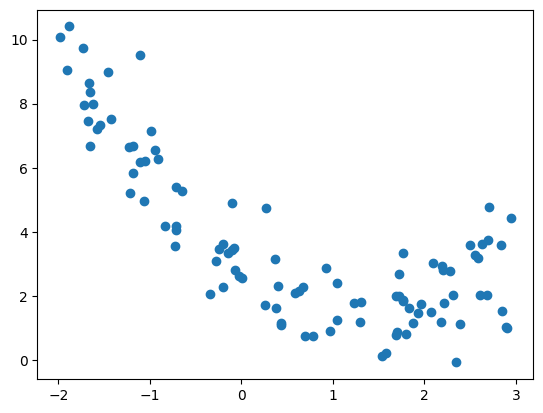

In [45]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [47]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [48]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

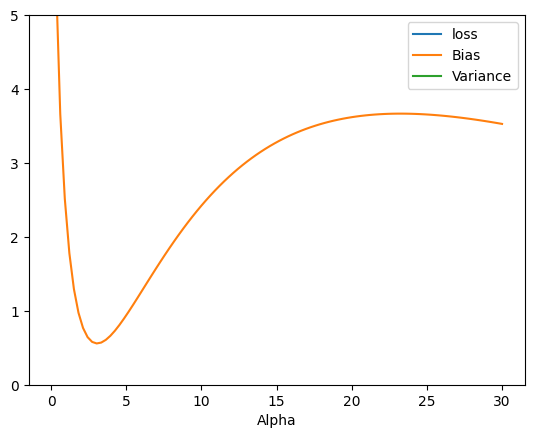

In [49]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()

#  Effect on the Loss Function

Linear Regression me loss sirf prediction error hota hai. Ridge Regression me loss = prediction error + large coefficients ki penalty. Isliye Gradient Descent loss ko kam karne ke liye prediction error ke saath-saath coefficients ko bhi chhota karta hai. Yahi Ridge Regression ka main effect on the loss function hai.

# Exmaple

In [ ]:
Story: School Competition

Maan lo school me ek competition hai.

Teacher ne bola:

"Jo student sabse kam galti karega, wahi winner hoga."

Ye Linear Regression hai.

Yaha sirf galti (Prediction Error) dekhi ja rahi hai.

Suppose:

Student A
Galti = 2
Student B
Galti = 4

Teacher bolega:

Student A winner.

Ab Ridge Regression aa gaya.

Naya teacher bolta hai:

"Sirf galti nahi dekhunga. Ye bhi dekhunga ki cheating ya unfair tricks to use nahi ki."

Machine Learning me unfair trick = Bahut bade coefficients.

Ab score banega:

Final Loss

=

Prediction Error

+

Penalty
Example
Model A

Prediction Error = 2

Coefficients

100

80

120

Bahut bade coefficients.

Penalty = 15

Final Loss

2 + 15 = 17
Model B

Prediction Error = 4

Coefficients

8

10

6

Penalty = 1

Final Loss

4 + 1 = 5
Kaun jeeta?

Agar sirf prediction error dekhte,

Model A

jeet jata.

Lekin Ridge bolta hai

"Model A ne bahut bade coefficients use kiye hain."

Isliye usko penalty mili.

Final loss

17

Model B ka

5

To Ridge ke hisaab se Model B better hai, kyunki usne thoda zyada error kiya, lekin model simple aur stable banaya.

Gradient Descent kya karega?

Gradient Descent ka goal hota hai

Loss ko kam karna.

Loss me ab penalty bhi hai.

To Gradient Descent sochega:

"Agar mujhe loss kam karna hai, to sirf prediction error hi nahi, coefficients bhi kam karne padenge."

Isliye har iteration me coefficients ko dheere-dheere chhota karta hai.

100 → 90 → 82 → 75 → 68 ...

Isi process ko Coefficient Shrinkage bolte hain.

# Code

[27.82809103]
-2.29474455867698


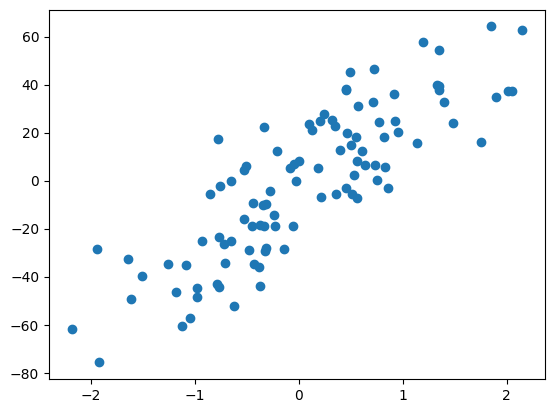

In [50]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [51]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [52]:
def predict(m):
    return m*X - 2.29

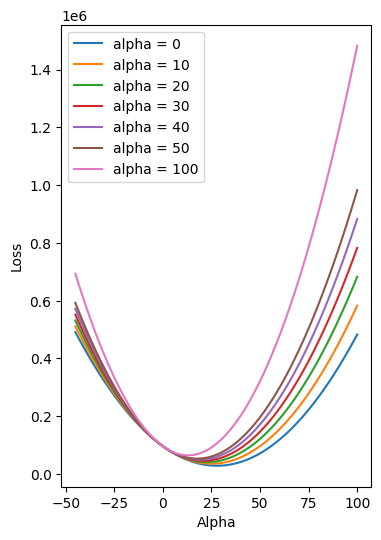

In [53]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()


# Why Ridge Regression is called so?

Ridge Regression ka naam "Ridge" isliye pada kyunki iske loss function me jab L2 penalty add ki jati hai, to optimization surface (loss surface) ki shape badal jati hai. Ye surface ek "ridge" (pahad ki lambi unchi line) jaisi dikhne lagti hai. Is mathematical shape ki wajah se is technique ka naam Ridge Regression rakha gaya.

 # Layman Analogy

Socho tum pahadon me chal rahe ho.

Ek normal pahad hai jahan sirf niche utarna hai.

Ye Linear Regression hai.

Ab kisi ne pahad ke beech me ek lambi ridge (pahad ki patli unchi line) bana di.

Ab tum seedha kahin bhi nahi ja sakte. Tumhe us ridge ko follow karte hue chalna padega.

Bilkul waise hi Ridge Regression me L2 penalty model ko restrict karti hai. Model coefficients ko bahut bada nahi hone deti aur optimization ko ek constrained path par chalati hai.